In [1]:
itest='Colorado_extRemes_LocSca_CV_CIos'

In [2]:
import os

# Set OMP_NUM_THREADS to 4
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"]="1"

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from copy import copy


In [4]:
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv


%load_ext rpy2.ipython

In [5]:
%R Sys.setenv(OMP_NUM_THREADS = 8)
%R Sys.setenv(OPENBLAS_NUM_THREADS = 8)
%R Sys.setenv(MKL_NUM_THREADS = 8)

1


In [6]:
extRemes = importr("extRemes")
twosamples = importr("twosamples")
dplyr = importr("dplyr")
%R source("R_utils.R")

In [7]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
%R options( warn = -1 )

In [ ]:
%%R -w 800 --type=cairo
 extremes_bootLS <- function(r_df,fevd_options,n,alpha,rp){

  # Regular bootstrap  

  ntime <- length(r_df[['AFI']])

  boot_RL <- array(NA, dim = c(ntime, length(rp),n))
  boot_Loc <- matrix(data = NA,nrow=ntime,ncol=n)
  boot_Scale <- matrix(data = NA,nrow=ntime,ncol=n)

  boot_LocDiff <- matrix(nrow=1,ncol=n)
  boot_ScaleDiff <- matrix(nrow=1,ncol=n)
  boot_RLDiff <- matrix(nrow=length(rp),ncol=n)
  RiskRatios <- matrix(nrow=length(rp),ncol=n)

  i<-1
  while (i < n){
      index <- 1:ntime
      bx <- sample(index, size = ntime, replace = TRUE)
      r_df['bglost']<- r_df[['glost']][bx]
      r_df['bAFI']<- r_df[['AFI']][bx]
      r_df['btime'] <- r_df[['time']][bx]
      initial_vals <- list(location = mean(r_df$bAFI), scale = sd(r_df$bAFI), shape = 0.1)
      call_fevd <- paste("fevd(bAFI, data = r_df,",gsub("glost", "bglost", fevd_options),")")
      fit <- eval(parse(text = call_fevd))            
      if (all(findpars(fit)$scale>0)){
          boot_rl <- return.level(fit, return.period = rp)
          boot_Loc[,i] <- findpars(fit)$location[order(r_df$btime)]
          boot_Scale[,i] <- findpars(fit)$scale[order(r_df$btime)]
          boot_RL[,,i] <- boot_rl[order(r_df$btime),]
          boot_LocDiff[i] <- boot_Loc[ntime,i] - boot_Loc[1,i]
          boot_ScaleDiff[i] <- boot_Scale[ntime,i] - boot_Scale[1,i]
          boot_RLDiff[,i] <- boot_RL[ntime,,i] - boot_RL[1,,i]
          RiskRatios[,i] <- pevd(q=boot_RL[ntime,,i],
                 loc=boot_Loc[1,i],
                 scale=boot_Scale[1,i],
                 shape=findpars(fit)$shape[1],
                 lower.tail=FALSE) / 0.01

          i <- i+1
      }     
      }     
  Diffloc_q <- apply(boot_LocDiff, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE)
  Diffsca_q <- apply(boot_ScaleDiff, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE)
  DiffRL_q <- t(apply(boot_RLDiff, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE))
  RR_q <- t(apply(RiskRatios, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE))
  loc_q <- t(apply(boot_Loc, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE))
  sca_q <- t(apply(boot_Scale, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE))
  RL_q <- apply(boot_RL, c(1,2), quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE)

  return(list(Dloc_q=Diffloc_q,Dsca_q=Diffsca_q,DRL_q=DiffRL_q,RR_q=RR_q,loc_q=loc_q,sca_q=sca_q,RL_q=RL_q))
  }
##########################  

In [ ]:
%%R -w 800 --type=cairo
extremes_bootGE_ <- function(m_gev,r_df,fevd_options,n,alpha,rp){
   ### Following E.Gilleland 2020.
   ntime <- length(r_df[['AFI']])
   fitter <- function(data,...,Fit){
   np <- length(rp)

   RL_q <- array(NA, dim = c(ntime, length(rp),3))
   DiffRL_q <- array(NA, dim = c(length(rp),3))
   RR_q <- array(NA, dim = c(length(rp),3))

   data <- data.frame(AFI=data,Fit$cov.data)
   initial_vals <- list(location = mean(data$AFI), scale = sd(data$AFI), shape = 0.1)
   call_fevd <- paste("fevd(AFI, data = data,",fevd_options,")")
   fit <- eval(parse(text = call_fevd))
   if (all(findpars(fit)$scale)>0){
        Loc <- findpars(fit)$location
        Scale <- findpars(fit)$scale
        DiffLoc <- findpars(fit)$location[ntime] - findpars(fit)$location[1]
        DiffScale <- findpars(fit)$scale[ntime] - findpars(fit)$scale[1]
        RL <- return.level(fit,return.period=rp)
        DiffRL <- RL[ntime,] - RL[1,]
        RR <- pevd(q=RL[ntime,],
                 loc=findpars(fit)$location[1],
                 scale=findpars(fit)$scale[1],
                 shape=findpars(fit)$shape[1],
                 lower.tail=FALSE) / 0.01

        out <- c(DiffLoc,DiffScale,DiffRL,RR,Loc,Scale,RL)
            return(out)
            }}
   simphx<-function(size,...,Fit){
            out<-c(rextRemes(Fit,size))
            return(out)
            }
   pboopted<-pbooter(x=r_df$AFI,statistic=fitter,B=n,rmodel=simphx,Fit=m_gev,verbose=FALSE)

   res<- ci(pboopted,na.rm=TRUE,type="perc",alpha=alpha)
   #
   Diffloc_q <- cbind(res$perc[1,1],res$perc[1,2],res$perc[1,3])
   Diffsca_q <- cbind(res$perc[2,1],res$perc[2,2],res$perc[2,3])
   DiffRL_q <- cbind(res$perc[3:as.integer(3+length(rp)-1),1],res$perc[3:integer(3+length(rp)-1),2],res$perc[3:integer(3+length(rp)-1),3])
   ib <- as.integer(3+length(rp))
   ie <- as.integer(3+length(rp)*2-1)
   RR_q <- cbind(res$perc[ib:ie,1],res$perc[ib:ie,2],res$perc[ib:ie,3])
   #              
   ib <- as.integer(3+length(rp)*2)
   ie <- as.integer(3+length(rp)*2+ntime-1)
   loc_q <- cbind(res$perc[ib:ie,1],res$perc[ib:ie,2],res$perc[ib:ie,3])
   ib <- as.integer(3+length(rp)*2+ntime)
   ie <- as.integer(3+length(rp)*2+ntime*2-1)
   sca_q <- cbind(res$perc[ib:ie,1],res$perc[ib:ie,2],res$perc[ib:ie,3])
   ib <- as.integer(3+length(rp)*2+ntime*2)
   ie <- as.integer(dim(res$perc)[1])
   RL_q <- cbind(res$perc[ib:ie,1],res$perc[ib:ie,2],res$perc[ib:ie,3])
   #

   return(list(Dloc_q=Diffloc_q,Dsca_q=Diffsca_q,DRL_q=DiffRL_q,RR_q=RR_q,loc_q=t(loc_q),sca_q=t(sca_q),RL_q=RL_q))
  }

# READ AFI, DJF Temperature and topography FILES

In [ ]:
yearb=1941
yeare=2025

ifile='ERA5_AFI_1941_2025.nc'

dso = xr.open_dataset(ifile)
dso = dso.sel(time=slice(f'{yearb}-01-01',f'{yeare}-02-01'))
dso = dso.sortby('lat')
dso['time'] = np.arange(yearb,yeare+1,1)
dso = dso.drop_vars({'freezing_begin_date', 'freezing_end_date'})

Tlon = dso.lon.data
Tlat = dso.lat.data

units = 'degree-days (°C)'

In [ ]:
dsj = xr.open_dataset('era5_Summer_snowd_mask.nc')
dsj = dsj.sel(lon=dso['lon'],lat=dso['lat'])
maskSd = dsj['maskSd']

In [14]:
dso['AFI'] = dso['AFI'].where(maskSd==1)

In [ ]:
fileGLOST = 'annual_LOESS_NOAA_GLOST_anomaly.nc'
ds_glost=xr.open_dataset(fileGLOST)
ann_glost = ds_glost['glost']
dso=dso.merge({'glost':ann_glost})

In [16]:
lon_min = 250.6
lon_max = 258.5
lat_min = 36.7
lat_max = 41.3

ds = dso.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))

Tlon = ds.lon.data
Tlat = ds.lat.data

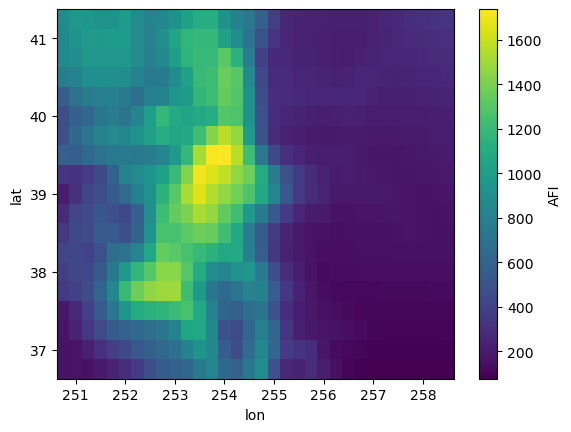

In [17]:
ds['AFI'].mean('time').plot()

In [18]:
return_periods = [2, 5, 10, 20, 50, 100]
%R rp <- c(2, 5, 10, 20, 50, 100)
K =5 # number of splits for Cross-Validation
%R K <- 5

array([5.])

In [19]:
%%R -w 800 --type=cairo
#===============================================================================
#===============================================================================
#===============================================================================
# function to define indices of rows of dataframe that assign observations to splits
# This function was written by Finn Lindgren
# ARGS:
# N: positive integer; (= number of rows of full dataframe)
# K: positive integer; (= number of splits for cross-validation)
# Value/Output: numeric of length N with indices 1,...,K defining random splitting into K subsets
cv_indices_splits <- function(N, K=K){
  split_sizes <-  ceiling((1:K)*N/K) - ceiling((0:(K-1))*N/K)
  sample(rep(1:K, times=split_sizes), size=N, replace=FALSE)
}
#===============================================================================
# function that takes data frame and splits/partitions in to training and test dataframes
# This function was written by Finn Lindgren
# ARGS:
# data: a data frame
# splits: index vector defining the K data splits (as produced by cv_indices_splits)
# k: the index k \in 1:K for the subset to be used as test/validation set
# Value/Output:
# a list with two named elements;
# 1.) Train: training data frame with rows of data in subsets with split index not equal to k
# 2.) Test: test data frame with rows of data in subsets with split index equal to k
cv_split <- function(data, splits, k){
  list(Train =  data[splits != k,  ,drop=FALSE],
       Test  =  data[splits == k,  ,drop=FALSE])
}

In [20]:
%%R -w 800 --type=cairo

cross_validation <- function(data,fevd_options,K){

#===============================================================================
# function that calls Mod_Train_Test for all for each of the K splits and collects the results
# ARGS:
# data: full data frame to be split in in to training/test sets
# splits: the splitting indices (as produced by cv_indices_splits)
# formula_list: a list of formulas as required by evgam

  AIC_cv <- NULL
  BIC_cv <- NULL
  scores <- list()  # note AIC/BIC need dealt with
  tests <- list()
  for(k in 1:5){
    data_k <- cv_split(data=data, splits=splits, k)
    call_fevd <- paste("fevd(AFI, data = data_k$Train,",fevd_options,")")
    mod <- eval(parse(text = call_fevd))
    pp <- summary(mod, silent = TRUE)
    if (length(pp$par)==3){
        location <- rep(pp$par[['location']],times =length(data_k$Test$time))
        scale <- rep(pp$par[['scale']],times =length(data_k$Test$time))
        shape <- rep(pp$par[['shape']],times =length(data_k$Test$time))
    } else if ((length(pp$par)==4)){
        location <- pp$par[['mu0']]+pp$par[['mu1']]*data_k$Test$glost
        scale <- rep(pp$par[['scale']],times =length(data_k$Test$time))
        shape <- rep(pp$par[['shape']],times =length(data_k$Test$time))
    } else if ((length(pp$par)==5)){
        location <- pp$par[['mu0']]+pp$par[['mu1']]*data_k$Test$glost
        scale <- pp$par[['sigma0']]+pp$par[['sigma1']]*data_k$Test$glost
        shape <- rep(pp$par[['shape']],times =length(data_k$Test$time))
    }
    params <-list(location=location,scale=scale,shape=shape)
    params['cell'] <- 1
    TrainAndTest <- list(mod.scores=GEV_scores(data_k$Test,params), mod.AIC=pp$AIC, mod.BIC=pp$BIC)

    scores[[k]] <- cbind(TrainAndTest[[1]], time=data_k$Test$time,split_k = k)
    AIC_cv[k] <- TrainAndTest[[2]]
    BIC_cv[k] <- TrainAndTest[[3]]
    tests[[k]] <- cbind(KS_CVM(data_k$Test,params), time=data_k$Test$time, split_k = k)
  }
  scores <- do.call(rbind, scores)
  tests <- do.call(rbind, tests)
  list(scores_cv=scores, tests_cv=tests, AIC_cv=AIC_cv, BIC_cv=BIC_cv)
}

In [21]:
%R set.seed(1)
%R splits <- cv_indices_splits(N=85, K=K)

array([4, 3, 1, 2, 3, 1, 4, 3, 2, 4, 5, 1, 5, 3, 5, 5, 3, 2, 3, 3, 3, 3,
       2, 2, 4, 4, 5, 4, 2, 1, 3, 5, 2, 4, 5, 4, 4, 2, 2, 5, 1, 2, 2, 3,
       4, 5, 3, 4, 5, 1, 1, 1, 4, 1, 5, 3, 3, 4, 5, 5, 5, 1, 4, 4, 2, 5,
       4, 1, 2, 2, 1, 4, 3, 1, 3, 3, 2, 1, 1, 1, 5, 2, 2, 5, 1],
      dtype=int32)

In [22]:
# Define arrays GEV output
location = xr.zeros_like(ds['AFI'])*np.nan
shape = xr.zeros_like(ds['AFI'])*np.nan
scale = xr.zeros_like(ds['AFI'])*np.nan
rl = xr.zeros_like(ds['AFI']).expand_dims(dim={'return_periods':return_periods})*np.nan
AIC = xr.zeros_like(ds['AFI'].mean('time'))*np.nan
BIC = xr.zeros_like(ds['AFI'].mean('time'))*np.nan
pvalueL = xr.zeros_like(ds['AFI'].mean('time'))*np.nan
pvalueS = xr.zeros_like(ds['AFI'].mean('time'))*np.nan

# Define arrays Confidence Interval 
location_q = xr.zeros_like(ds['AFI']).expand_dims(quantile=[0.05,0.5,0.95])*np.nan
scale_q = xr.zeros_like(ds['AFI']).expand_dims(quantile=[0.05,0.5,0.95])*np.nan
rl_q = xr.zeros_like(ds['AFI']).expand_dims(quantile=[0.05,0.5,0.95]).expand_dims(dim={'return_periods':return_periods})*np.nan
Dlocation_q = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(quantile=[0.05,0.5,0.95])*np.nan
Dscale_q = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(quantile=[0.05,0.5,0.95])*np.nan
Drl_q = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(quantile=[0.05,0.5,0.95]).expand_dims(dim={'return_periods':return_periods})*np.nan
rr_q = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(quantile=[0.05,0.5,0.95]).expand_dims(dim={'return_periods':return_periods})*np.nan

# Define arrays Cross-Validation
SE_cv = xr.zeros_like(ds['AFI'])*np.nan
DawSeb_cv = xr.zeros_like(ds['AFI'])*np.nan
CRPS_cv = xr.zeros_like(ds['AFI'])*np.nan
WCRPS_cv = xr.zeros_like(ds['AFI'])*np.nan
KS_D_cv = xr.zeros_like(ds['AFI'])*np.nan
KS_pvalue_cv = xr.zeros_like(ds['AFI'])*np.nan
CVM_D_cv = xr.zeros_like(ds['AFI'])*np.nan
CVM_pvalue_cv = xr.zeros_like(ds['AFI'])*np.nan
AIC_cv = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(split=K)*np.nan
BIC_cv = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(split=K)*np.nan

In [23]:
%R fevd_options <- "type='GEV',method='MLE', initial = initial_vals, location.fun = ~ glost, scale.fun = ~ glost"

array(["type='GEV',method='MLE', initial = initial_vals, location.fun = ~ glost, scale.fun = ~ glost"],
      dtype='<U92')

In [ ]:


mask=xr.where(np.isnan(ds['AFI'].mean('time'))==False,1,0)

idlat,idlon=np.where(mask==1)
for ij in range(0,1):
  jj=idlat[ij]
  ii=idlon[ij]
  ilon=257.5
  ilat=37.5


  # Extract values for boxes
  dsij=ds.sel(lon=ilon,lat=ilat)
  df = dsij.to_dataframe()
  df = df.reset_index()

  df= df.assign(cell=1)
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave=df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  dfsave=pd.concat([dfsave, df.groupby(['lon', 'lat']).filter(lambda x: len(x) <= 49)])
  df=df.groupby(['lon', 'lat']).filter(lambda x: len(x) > 49)

  itime = df['time'].values
  ntime = len(itime)
  if df.empty == False: 
    # Convert xarray to pandas DataFrame to R data.frame
    # You can now work with 'r_df' in R

    with (ro.default_converter + pandas2ri.converter).context():
      r_df = ro.conversion.get_conversion().py2rpy(df)
    globalenv['r_df'] = r_df

    # Extremes GEV model fitting  
    %R initial_vals <- list(location = mean(r_df[['AFI']]), scale = sd(r_df[['AFI']]), shape = 0.1)
    %R call_fevd <- paste("fevd(AFI, data = r_df,",fevd_options,")")
    %R m_gev <- eval(parse(text = call_fevd))
    %R m_gevL <- fevd(AFI, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ glost)
    %R m_gevS <- fevd(AFI, data = r_df,type='GEV',method='MLE', initial = initial_vals )
    %R pp <- summary(m_gev, silent = TRUE)
    %R rpvalueL <- lr.test(m_gevS, m_gevL)$p.value
    %R rpvalueS <- lr.test(m_gevL, m_gev)$p.value
    %R convergence <- m_gev$results$convergence
    %R -o convergence,rpvalueL,rpvalueS
    %R loc <- findpars(m_gev)$location
    %R sca <- findpars(m_gev)$scale
    %R sha <- findpars(m_gev)$shape
    %R rAIC <- pp$AIC
    %R rBIC <- pp$BIC
    %R -o loc,sca,sha,rAIC,rBIC
    if sca.all() > 0.:
        %R gev_rl <- return.level(m_gev, return.period = rp)
        %R -o gev_rl
        ######
        # Cross-Validation
        ######

        %R params <-list(location=loc,scale=sca,shape=sha)
        %R params['cell'] <- 1
        %R tests_scores <- cross_validation(r_df,fevd_options,K)
        %R ktime <- tests_scores$scores_cv$time
        %R df_ks_cvm <- tests_scores$tests
        %R SE <- tests_scores$scores_cv$SE
        %R DawSeb <- tests_scores$scores_cv$DawSeb
        %R CRPS <- tests_scores$scores_cv$CRPS      
        %R rAIC_cv <- tests_scores$AIC_cv
        %R rBIC_cv <- tests_scores$BIC_cv
        %R -o ktime,SE,DawSeb,CRPS,df_ks_cvm,rAIC_cv,rBIC_cv
        ######
        # Confidence Intervals
        ######

        #%R boot <- extremes_bootGE_(m_gev,r_df,fevd_options,1000,0.1,rp) 
        %R boot <- extremes_bootLS(r_df,fevd_options,1000,0.1,rp) # Regular bootstrap
        %R DLoc_qr <- boot$Dloc_q
        %R DScale_qr <- boot$Dsca_q
        %R DRL_qr <- boot$DRL_q
        %R RR_qr <- boot$RR_q
        %R Loc_qr <- boot$loc_q
        %R Scale_qr <- boot$sca_q
        %R RL_qr <- boot$RL_q
        %R -o DLoc_qr,DScale_qr,DRL_qr,RR_qr,Loc_qr,Scale_qr,RL_qr
        ######
        # Write output
        ######

        location.loc[{'time':itime,'lat':ilat,'lon':ilon}] = loc
        scale.loc[{'time':itime,'lat':ilat,'lon':ilon}] = sca
        shape.loc[{'time':itime,'lat':ilat,'lon':ilon}] = sha
        for irp in range(0,len(return_periods)):
          rl.loc[{'time':itime,'lat':ilat,'lon':ilon,'return_periods':return_periods[irp]}] = gev_rl[:,irp]
        AIC.loc[{'lat':ilat,'lon':ilon}] = rAIC.item()
        BIC.loc[{'lat':ilat,'lon':ilon}] = rBIC.item()
        pvalueL.loc[{'lat':ilat,'lon':ilon}] = rpvalueL.item()
        pvalueS.loc[{'lat':ilat,'lon':ilon}] = rpvalueS.item()

        # CV
        SE_cv.loc[{'time':ktime,'lat':ilat,'lon':ilon}] = SE
        DawSeb_cv.loc[{'time':ktime,'lat':ilat,'lon':ilon}] = DawSeb
        CRPS_cv.loc[{'time':ktime,'lat':ilat,'lon':ilon}] = CRPS
        KS_D_cv.loc[{'time':ktime,'lat':ilat,'lon':ilon}] = df_ks_cvm['KS_D'].values
        KS_pvalue_cv.loc[{'time':ktime,'lat':ilat,'lon':ilon}] = df_ks_cvm['KS_pvalue'].values
        CVM_D_cv.loc[{'time':ktime,'lat':ilat,'lon':ilon}] = df_ks_cvm['CVM_D'].values
        CVM_pvalue_cv.loc[{'time':ktime,'lat':ilat,'lon':ilon}] = df_ks_cvm['CVM_pvalue'].values
        AIC_cv.loc[{'lat':ilat,'lon':ilon}] = rAIC_cv
        BIC_cv.loc[{'lat':ilat,'lon':ilon}] = rBIC_cv

        # CI
        Dlocation_q.loc[{'lat':ilat,'lon':ilon}] = DLoc_qr[0,:].T
        Dscale_q.loc[{'lat':ilat,'lon':ilon}] = DScale_qr[0,:].T
        location_q.loc[{'time':itime,'lat':ilat,'lon':ilon}] = Loc_qr.T
        scale_q.loc[{'time':itime,'lat':ilat,'lon':ilon}] = Scale_qr.T
        for irp in range(0,len(return_periods)):
          Drl_q.loc[{'lat':ilat,'lon':ilon,'return_periods':return_periods[irp]}] = DRL_qr[irp,:]
          rr_q.loc[{'lat':ilat,'lon':ilon,'return_periods':return_periods[irp]}] = RR_qr[irp,:]
          rl_q.loc[{'time':itime,'lat':ilat,'lon':ilon,'return_periods':return_periods[irp]}] = RL_qr[:,:,irp]



In [58]:
%R k<-1
%R data_k<-cv_split(data=r_df, splits=splits, k)

In [60]:
%R data_k$Test

,time,AFI,lat,lon,glost,cell
2,1943,31.167480,37.5,257.5,0.011531,1
5,1946,49.989014,37.5,257.5,0.019687,1
11,1952,43.659058,37.5,257.5,0.008264,1
29,1970,80.412354,37.5,257.5,0.044925,1
40,1981,56.585449,37.5,257.5,0.202752,1
49,1990,106.968384,37.5,257.5,0.342288,1
50,1991,161.228638,37.5,257.5,0.357262,1
51,1992,54.698975,37.5,257.5,0.373023,1
53,1994,87.464966,37.5,257.5,0.407065,1
61,2002,44.023682,37.5,257.5,0.547738,1


In [24]:
ptlon = [253.75,257.5]
ptlat = [ 39.5 , 37.5]

Text(0.5, 0.98, 'Location parameter CI - Model 2')

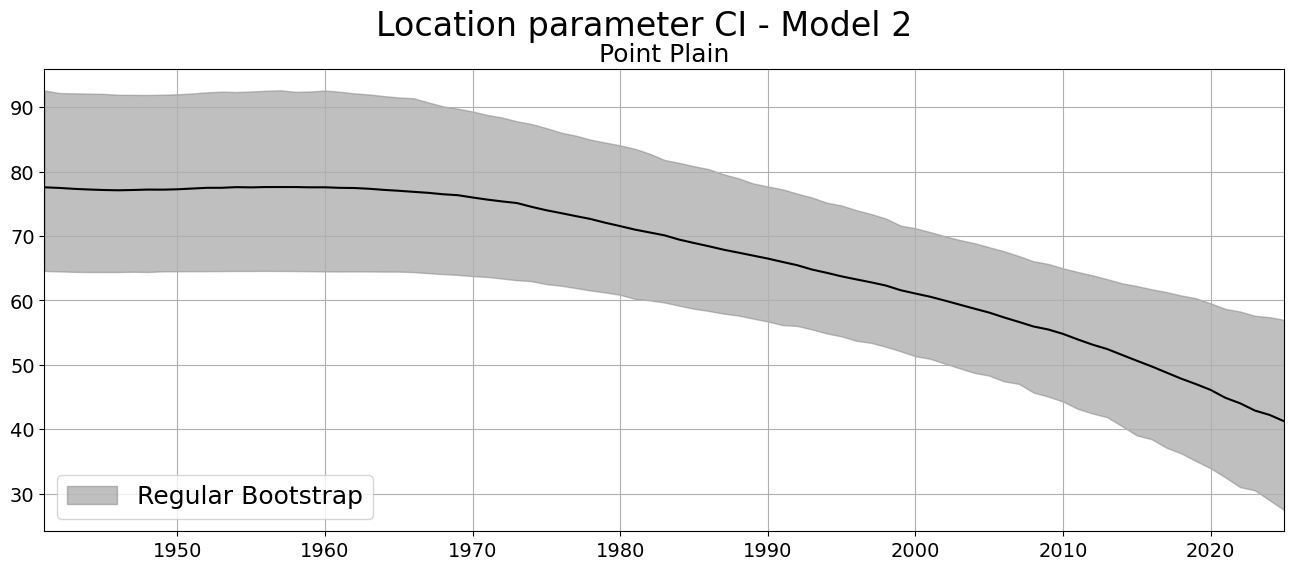

In [31]:
Ttitles=['Point Plain']
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,6))
k=0


ax.plot(ds.time,location_q.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.5),color='k')
ax.fill_between(ds.time, location_q.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.05),\
                   location_q.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.95), 
                color='gray', alpha=0.5, label='Regular Bootstrap')

ax.grid()
ax.set_xlim(yearb,yeare)
ax.set_title(f'{Ttitles[0]}',fontsize=18)
ax.tick_params(axis='both', labelsize=14)
ax.legend(loc='lower left',ncol=2,fontsize=18) 

plt.suptitle(f"Location parameter CI - Model 2",fontsize=24)

Text(0.5, 0.98, 'Return Level CI - Model 2')

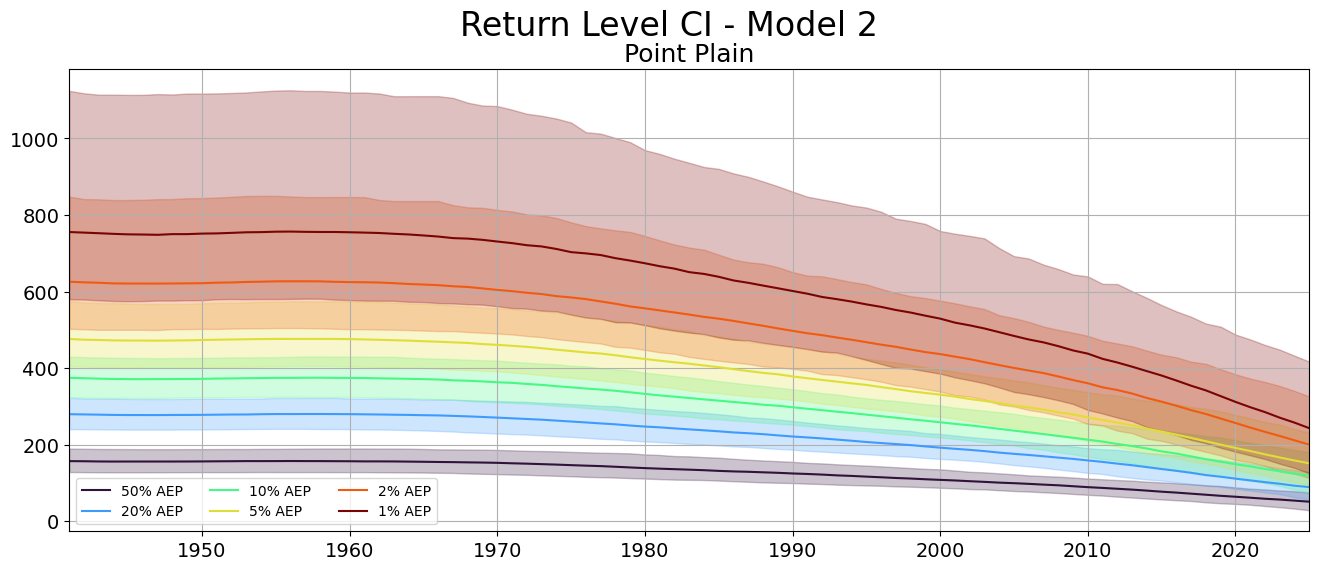

In [ ]:
from matplotlib import cm
turbo_colors = colors=cm.get_cmap('turbo',6)


fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,6))
k=0
for irp in range(0,len(return_periods)):
  ax.plot(np.arange(yearb,yeare+1),RL_q[1,:,irp],color=turbo_colors(k),label=f'{int(1/return_periods[irp]*100)}% AEP')
  ax.fill_between(np.arange(yearb,yeare+1),RL_q[0,:,irp],RL_q[2,:,irp], 
                color=turbo_colors(k), alpha=0.25)
  k = k+1
ax.legend(loc='lower left',ncol=3) 
ax.grid()
ax.set_xlim(yearb,yeare)

ax.set_title(f'{Ttitles[0]}',fontsize=18)
ax.tick_params(axis='both', labelsize=14)
plt.suptitle(f"Return Level CI - Model 2",fontsize=24)  

# Parametric Bootstrap

In [62]:
%R boot1000 <- extremes_bootGE_(m_gev,r_df,fevd_options,10000,0.1,rp)
%R Loc_qr10000 <- boot1000$loc_q
%R Scale_qr10000 <- boot1000$sca_q
%R RL_qr10000 <- boot1000$RL_q
%R -o Loc_qr10000,Scale_qr1000,RL_qr10000

In [36]:
%R boot5000 <- extremes_bootGE_(m_gev,r_df,fevd_options,5000,0.1,rp)
%R Loc_qr5000 <- boot5000$loc_q
%R Scale_qr5000 <- boot5000$sca_q
%R RL_qr5000 <- boot5000$RL_q
%R -o Loc_qr5000,Scale_qr5000,RL_qr5000

In [26]:
%R boot2000 <- extremes_bootGE_(m_gev,r_df,fevd_options,2000,0.1,rp)
%R Loc_qr2000 <- boot2000$loc_q
%R Scale_qr2000 <- boot2000$sca_q
%R RL_qr2000 <- boot2000$RL_q
%R -o Loc_qr2000,Scale_qr2000,RL_qr2000

In [27]:
%R boot1000 <- extremes_bootGE_(m_gev,r_df,fevd_options,1000,0.1,rp)
%R Loc_qr1000 <- boot1000$loc_q
%R Scale_qr1000 <- boot1000$sca_q
%R RL_qr1000 <- boot1000$RL_q
%R -o Loc_qr1000,Scale_qr1000,RL_qr1000

In [28]:
%R boot500 <- extremes_bootGE_(m_gev,r_df,fevd_options,500,0.1,rp)
%R Loc_qr500 <- boot500$loc_q
%R Scale_qr500 <- boot500$sca_q
%R RL_qr500 <- boot500$RL_q
%R -o Loc_qr500,Scale_qr500,RL_qr500

In [43]:
%R boot200 <- extremes_bootGE_(m_gev,r_df,fevd_options,200,0.1,rp)
%R Loc_qr200 <- boot200$loc_q
%R Scale_qr200 <- boot200$sca_q
%R RL_qr200 <- boot200$RL_q
%R -o Loc_qr200,Scale_qr200,RL_qr200

In [48]:
CB_color = [ '#f781bf','#984ea3','#e41a1c',\
             '#a65628','#ff7f00','#dede00',\
             '#377eb8','#4daf4a','#999999']

In [64]:
CB_color = [ '#a65628','#dede00','#e41a1c',\
             '#377eb8','#4daf4a','#ff7f00',\
             '#f781bf','#984ea3','#999999']

Text(0.5, 0.98, 'Location parameter CI - Model 2')

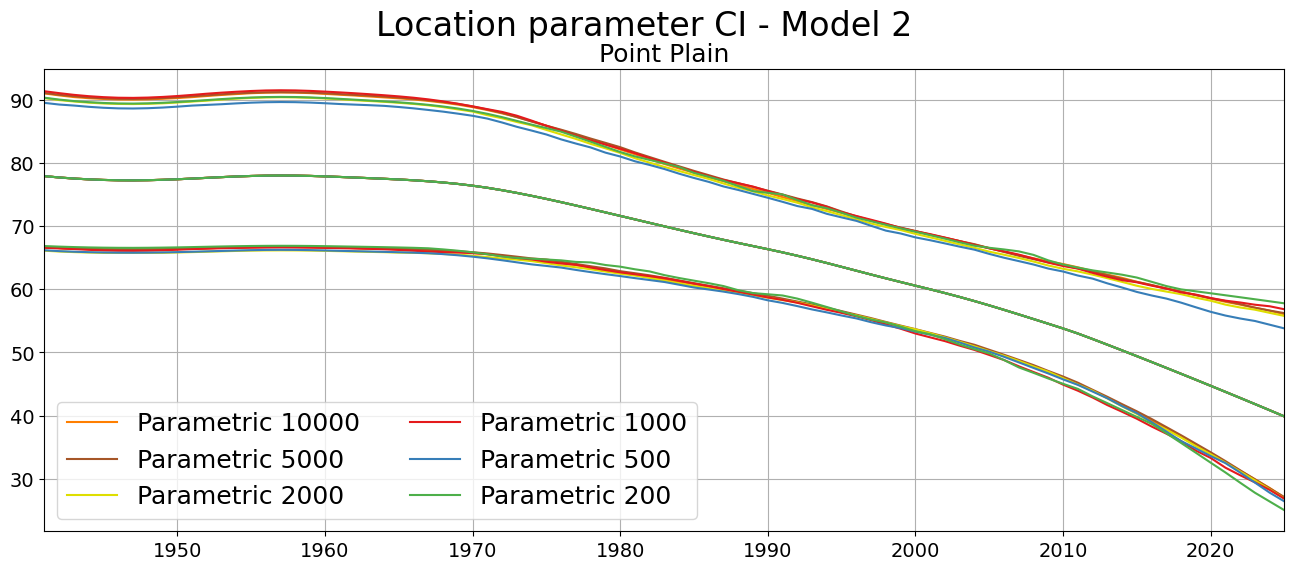

In [68]:
Ttitles=['Point Plain']
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,6))
k=0

ax.plot(ds.time,Loc_qr10000[0,:],color=CB_color[5])
ax.plot(ds.time,Loc_qr10000[1,:],color=CB_color[5], label='Parametric 10000')
ax.plot(ds.time,Loc_qr10000[2,:],color=CB_color[5])

ax.plot(ds.time,Loc_qr5000[0,:],color=CB_color[0])
ax.plot(ds.time,Loc_qr5000[1,:],color=CB_color[0], label='Parametric 5000')
ax.plot(ds.time,Loc_qr5000[2,:],color=CB_color[0])

ax.plot(ds.time,Loc_qr2000[0,:],color=CB_color[1])
ax.plot(ds.time,Loc_qr2000[1,:],color=CB_color[1], label='Parametric 2000')
ax.plot(ds.time,Loc_qr2000[2,:],color=CB_color[1])

ax.plot(ds.time,Loc_qr1000[0,:],color=CB_color[2])
ax.plot(ds.time,Loc_qr1000[1,:],color=CB_color[2], label='Parametric 1000')
ax.plot(ds.time,Loc_qr1000[2,:],color=CB_color[2])

ax.plot(ds.time,Loc_qr500[0,:],color=CB_color[3])
ax.plot(ds.time,Loc_qr500[1,:],color=CB_color[3], label='Parametric 500')
ax.plot(ds.time,Loc_qr500[2,:],color=CB_color[3])

ax.plot(ds.time,Loc_qr200[0,:],color=CB_color[4])
ax.plot(ds.time,Loc_qr200[1,:],color=CB_color[4], label='Parametric 200')
ax.plot(ds.time,Loc_qr200[2,:],color=CB_color[4])

ax.grid()
ax.set_xlim(yearb,yeare)
ax.set_title(f'{Ttitles[0]}',fontsize=18)
ax.tick_params(axis='both', labelsize=14)
ax.legend(loc='lower left',ncol=2,fontsize=18) 

plt.suptitle(f"Location parameter CI - Model 2",fontsize=24)

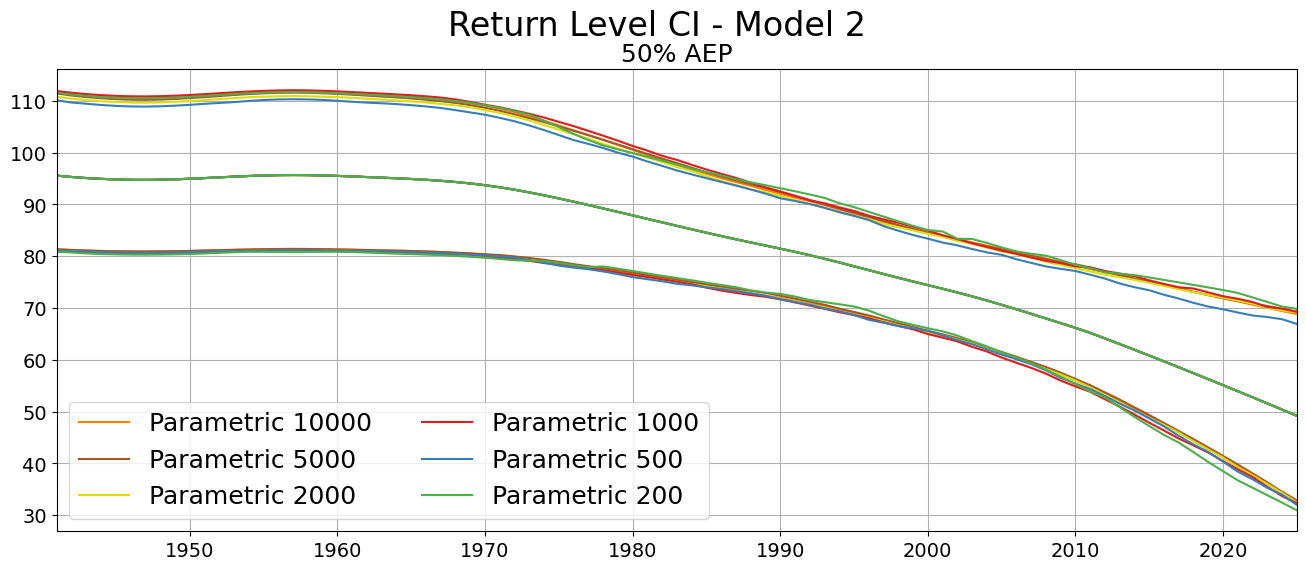

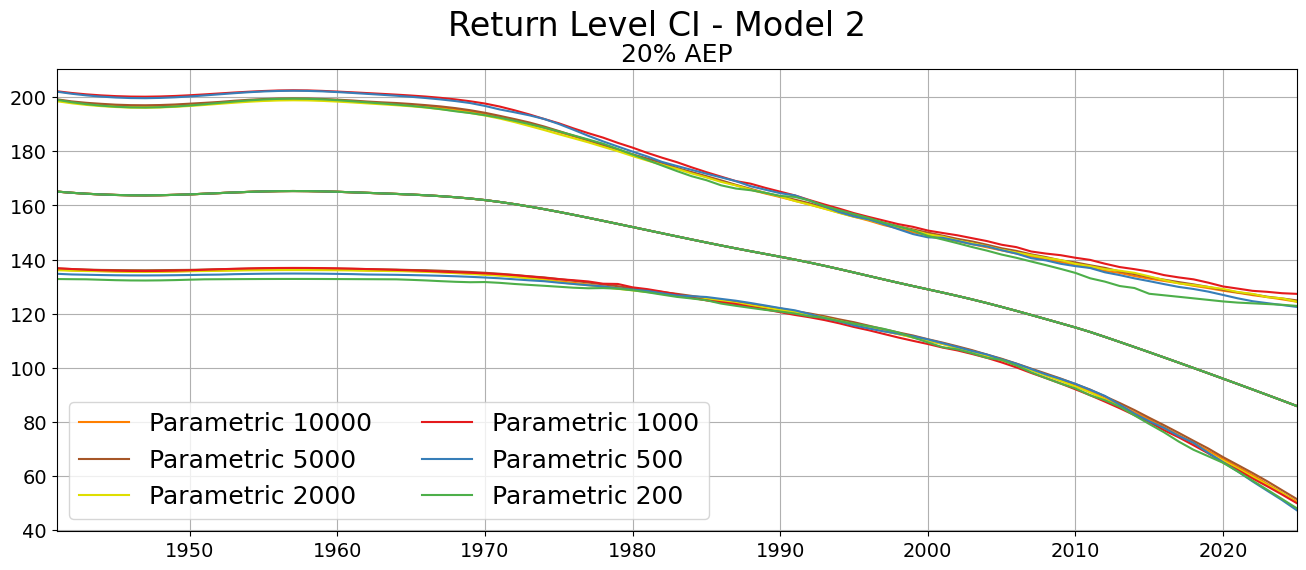

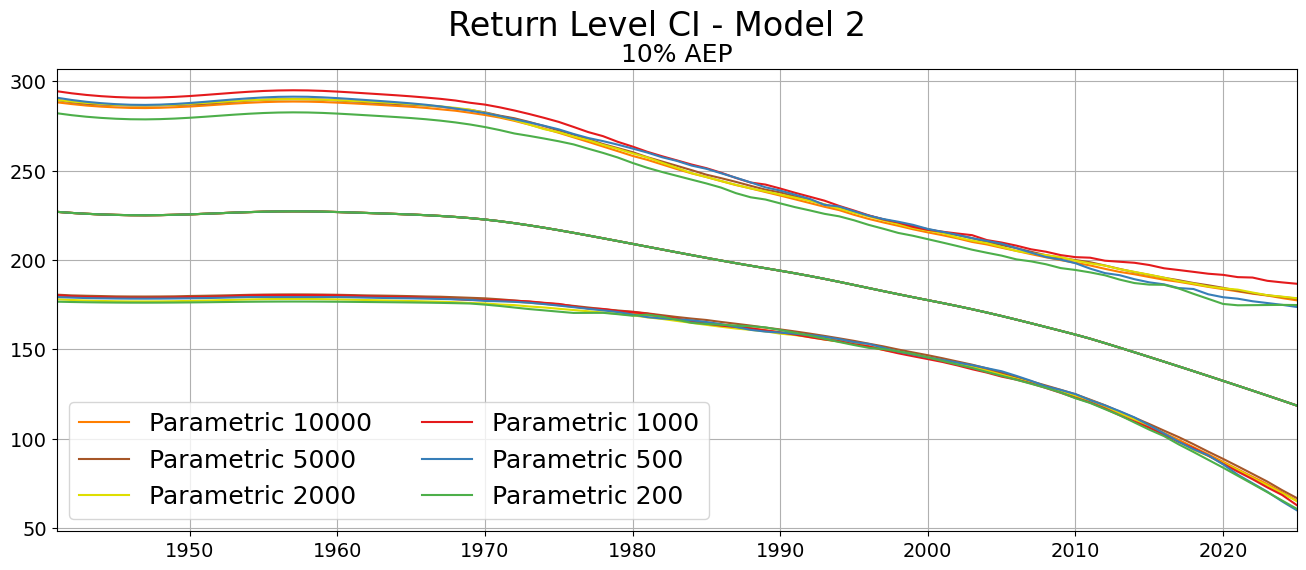

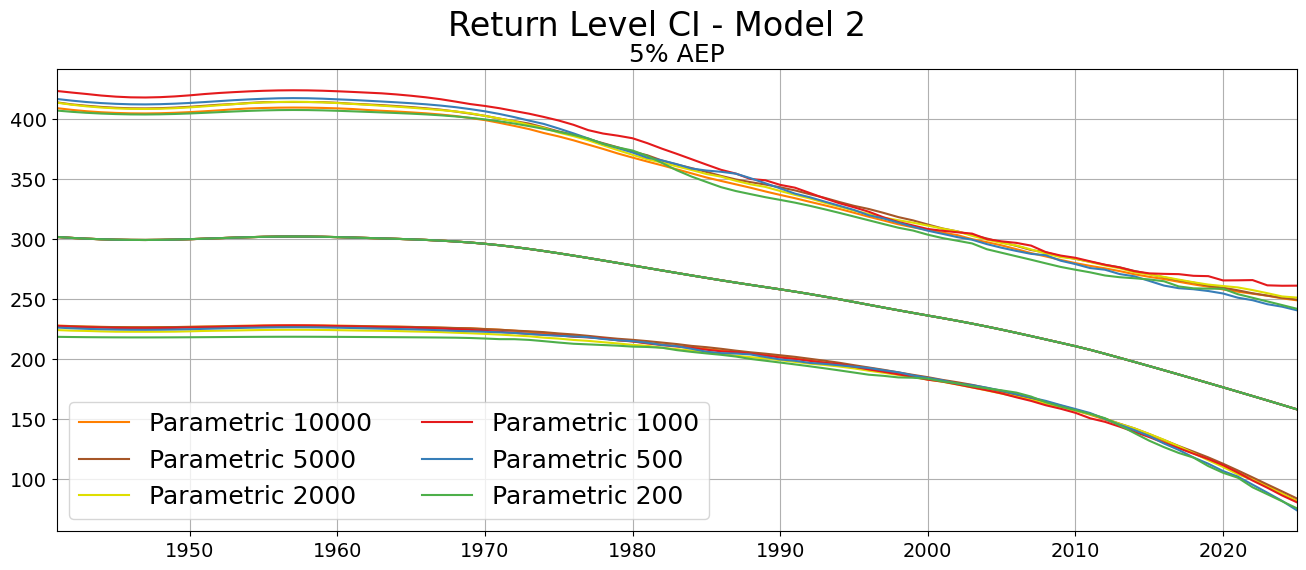

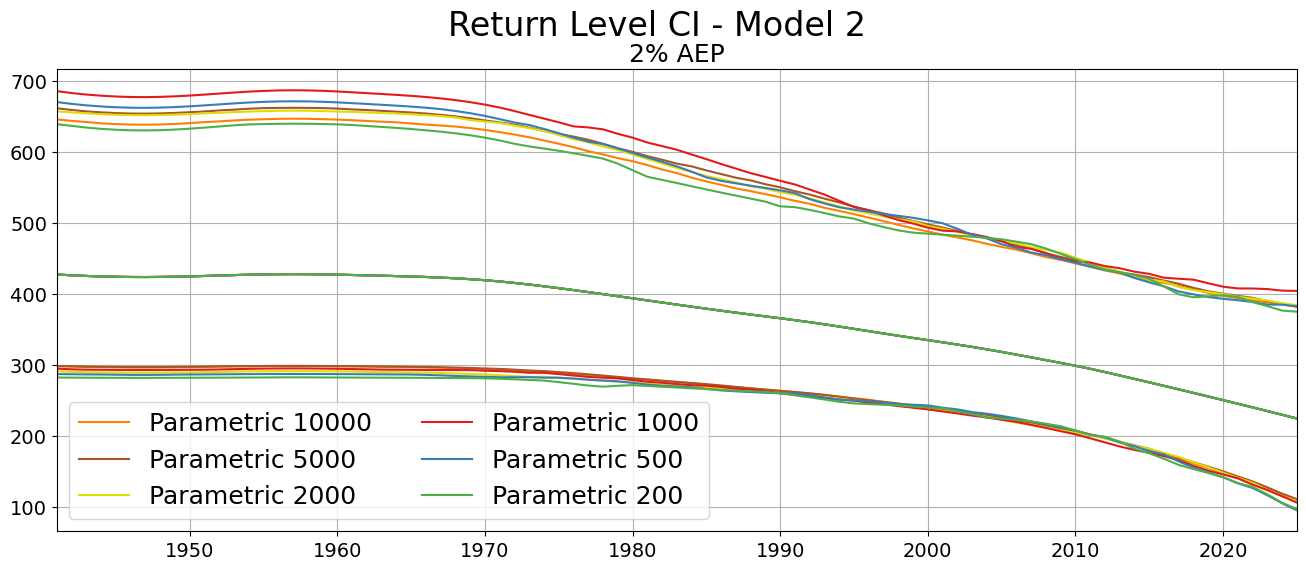

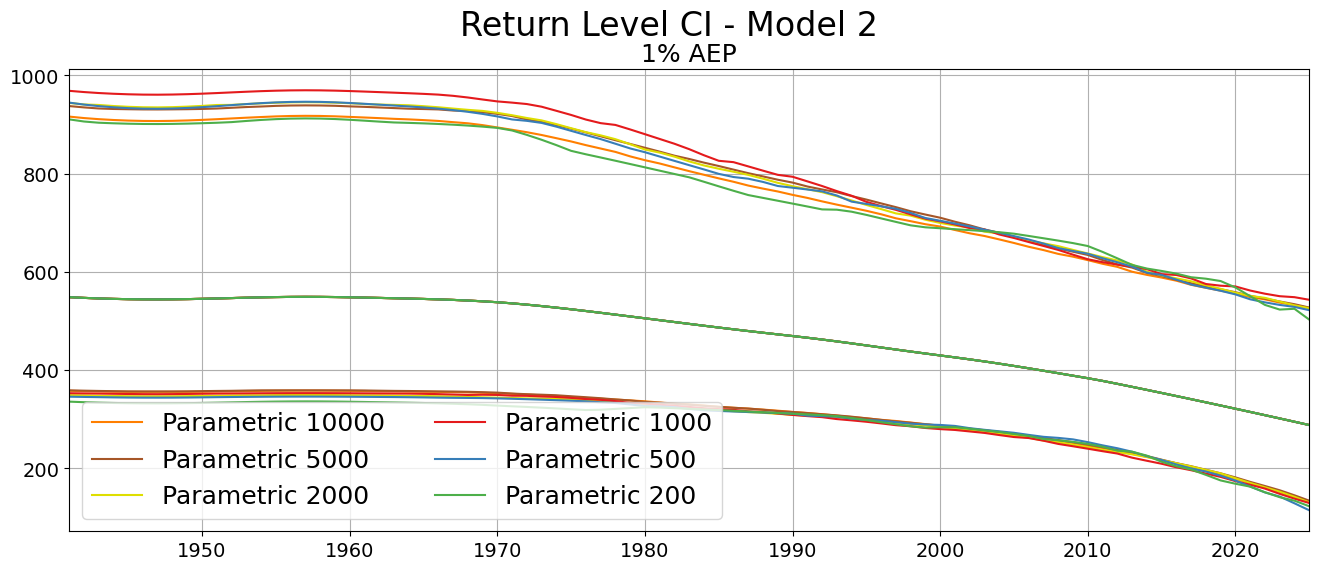

In [66]:
Ttitles=['Point Plain']

for irp in range(0,len(return_periods)):
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,6))
 
  ax.plot(ds.time,RL_qr10000.reshape(len(return_periods),ntime,3)[irp,:,0],color=CB_color[5])
  ax.plot(ds.time,RL_qr10000.reshape(len(return_periods),ntime,3)[irp,:,1],color=CB_color[5], label='Parametric 10000')
  ax.plot(ds.time,RL_qr10000.reshape(len(return_periods),ntime,3)[irp,:,2],color=CB_color[5])

  ax.plot(ds.time,RL_qr5000.reshape(len(return_periods),ntime,3)[irp,:,0],color=CB_color[0])
  ax.plot(ds.time,RL_qr5000.reshape(len(return_periods),ntime,3)[irp,:,1],color=CB_color[0], label='Parametric 5000')
  ax.plot(ds.time,RL_qr5000.reshape(len(return_periods),ntime,3)[irp,:,2],color=CB_color[0])

  ax.plot(ds.time,RL_qr2000.reshape(len(return_periods),ntime,3)[irp,:,0],color=CB_color[1])
  ax.plot(ds.time,RL_qr2000.reshape(len(return_periods),ntime,3)[irp,:,1],color=CB_color[1], label='Parametric 2000')
  ax.plot(ds.time,RL_qr2000.reshape(len(return_periods),ntime,3)[irp,:,2],color=CB_color[1])

  ax.plot(ds.time,RL_qr1000.reshape(len(return_periods),ntime,3)[irp,:,0],color=CB_color[2])
  ax.plot(ds.time,RL_qr1000.reshape(len(return_periods),ntime,3)[irp,:,1],color=CB_color[2], label='Parametric 1000')
  ax.plot(ds.time,RL_qr1000.reshape(len(return_periods),ntime,3)[irp,:,2],color=CB_color[2])

  ax.plot(ds.time,RL_qr500.reshape(len(return_periods),ntime,3)[irp,:,0],color=CB_color[3])
  ax.plot(ds.time,RL_qr500.reshape(len(return_periods),ntime,3)[irp,:,1],color=CB_color[3], label='Parametric 500')
  ax.plot(ds.time,RL_qr500.reshape(len(return_periods),ntime,3)[irp,:,2],color=CB_color[3])

  ax.plot(ds.time,RL_qr200.reshape(len(return_periods),ntime,3)[irp,:,0],color=CB_color[4])
  ax.plot(ds.time,RL_qr200.reshape(len(return_periods),ntime,3)[irp,:,1],color=CB_color[4], label='Parametric 200')
  ax.plot(ds.time,RL_qr200.reshape(len(return_periods),ntime,3)[irp,:,2],color=CB_color[4])
  ax.grid()
  ax.set_xlim(yearb,yeare)
  ax.set_title(f'{int(1/return_periods[irp]*100)}% AEP',fontsize=18)
  ax.tick_params(axis='both', labelsize=14)
  ax.legend(loc='lower left',ncol=2,fontsize=18) 

  plt.suptitle(f"Return Level CI - Model 2",fontsize=24)  